# Ejercicio 2 - Práctica 2

Lea en Colab el archivo `incendios-cantidad-causas-provincia_2022.csv` y realice cualquier tarea de limpieza y/o adecuación del dataset que considere necesaria.

1. Obtenga el número de incendios totales por año para todo el país. ¿Cuál fue el año en el que se presentó un mayor número de incendios?

2. Obtenga el número de incendios totales por año para el período 1993-2021 en la provincia de Córdoba.

3. Realice una tabla en la que se muestre, para cada año del periodo 1993-2021, la provincia en la que tuvo lugar el mayor número de incendios intencionales. Sugerencia: explore las funcionalidades del método `idxmax()` de la librería Pandas.

4. Realice un gráfico de barras para visualizar el número de incendios intencionales, por negligencia y naturales que tuvieron lugar durante el periodo 2015-2021 en la provincia de Santa Fe.

5. Obtenga el número promedio de incendios intencionales, por negligencia y naturales para la provincia de Río Negro durante el periodo 1993-2021.

# Lectura, limpieza y adecuación

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [173]:
'''
Al usar el comando "pr.read_csv" sin parámetros opcionales nos retorna un error

    'utf-8' codec can't decode byte 0xf1

Ese 0xf1 es la ñ. Probablemente el csv está en latin-1.
'''

df = pd.read_csv('../datasets/incendios-cantidad-causas-provincia_2022.csv', encoding = 'latin-1')
df

,El siguiente datasel contiene el numero de incendios total por provincia y las causas de dichos incendios por año para el periodo 1993-2022.,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Este y otros datasets de la temática pueden de...,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,anio,provincia,total,negligencia,intencional,natural,desconocida
3,1993,Buenos Aires,0,0,0,0,0
4,1993,Catamarca,0,0,0,0,0
...,...,...,...,...,...,...,...
674,2021,Santa Cruz,15,0,0,0,15
675,2021,Santa Fe,102,0,51,0,51
676,2021,Santiago del Estero,6,0,0,0,6
677,2021,Tierra del Fuego,24,23,0,0,1


In [174]:
'''
Observamos que los encabezados están en la fila 3 del csv.
'''

df = pd.read_csv('../datasets/incendios-cantidad-causas-provincia_2022.csv', encoding='latin-1', header = 3)
df

,anio,provincia,total,negligencia,intencional,natural,desconocida
0,1993,Buenos Aires,0,0,0,0,0
1,1993,Catamarca,0,0,0,0,0
2,1993,Chaco,0,0,0,0,0
3,1993,Chubut,21,18,0,0,3
4,1993,Córdoba,151,0,0,0,151
...,...,...,...,...,...,...,...
671,2021,Santa Cruz,15,0,0,0,15
672,2021,Santa Fe,102,0,51,0,51
673,2021,Santiago del Estero,6,0,0,0,6
674,2021,Tierra del Fuego,24,23,0,0,1


In [175]:
'''
Observamos que no faltan valores en el conjunto de datos. 
Además, los tipos de datos son en su mayoría consistentes con la 
naturaleza de cada variable salvo por la variable 'natural'.
Vamos a convertir el tipo en númerico (int64).
'''

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 676 entries, 0 to 675
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   anio         676 non-null    int64
 1   provincia    676 non-null    str  
 2   total        676 non-null    int64
 3   negligencia  676 non-null    int64
 4   intencional  676 non-null    int64
 5   natural      676 non-null    str  
 6   desconocida  676 non-null    int64
dtypes: int64(5), str(2)
memory usage: 44.2 KB


In [176]:
'''
Cambiamos el tipo a la columna 'natural'. Primero observemos qué valores tiene la columna.
Notemos que hay un valor '-' que representa un valor faltante.
'''

print(df['natural'].unique())
print("Cantidad de valores iguales a '-': ", (df['natural']=='-').sum())

<ArrowStringArray>
[  '0',   '3',   '1',   '2',  '67',  '24',   '-',   '8',  '22',  '11',   '7',
  '27', '176',  '63',   '4',   '5',  '37',  '26',  '15', '836',  '16',  '12',
  '20', '642',  '40',  '10',  '51', '188',  '13',  '50',   '9', '294', '128',
  '47', '222', '121', '400',  '31',  '33',  '44',  '45', '101', '373',   '6',
  '38',  '56', '148', '309',  '17',  '14',  '34',  '71', '547',  '66',  '18',
  '85',  '68', '302',  '19',  '60',  '48',  '57', '249',  '52',  '32', '706',
  '49',  '96',  '28',  '91',  '30', '591',  '54',  '43',  '46',  '58',  '92',
  '59',  '39',  '61', '114', '441',  '21', '100',  '89']
Length: 85, dtype: str
Cantidad de valores iguales a '-':  2


In [187]:
'''
Cambiamos los valores iguales a '-' por o ya que son solo 2 valores. 
Luego, damos el formato numérico tipo int.
'''

df['natural'] = df['natural'].replace('-', 0).astype(int)
df['natural'].unique()

array([  0,   3,   1,   2,  67,  24,   8,  22,  11,   7,  27, 176,  63,
         4,   5,  37,  26,  15, 836,  16,  12,  20, 642,  40,  10,  51,
       188,  13,  50,   9, 294, 128,  47, 222, 121, 400,  31,  33,  44,
        45, 101, 373,   6,  38,  56, 148, 309,  17,  14,  34,  71, 547,
        66,  18,  85,  68, 302,  19,  60,  48,  57, 249,  52,  32, 706,
        49,  96,  28,  91,  30, 591,  54,  43,  46,  58,  92,  59,  39,
        61, 114, 441,  21, 100,  89])

In [178]:
'''
Chequeamos que las pronvincias estén bien tipeadas. 

Al hacer esto, podemos observar que la provincia 'Santa Fe' está cargada tres veces.
Los duplicados vienen de agregar un espacio a izquierda y derecha. Vamos a cambiar esto.
También observamos que la variable 'Córdoba' aparece sin tilde.

También vamos a notar que 'Ciudad Autónoma de Buenos Aires' y 'Parques Nacionales'
no son provincias. Esto no genera un problema en el análisis.
'''

df['provincia'].unique()

<ArrowStringArray>
[                   'Buenos Aires',                       'Catamarca',
                           'Chaco',                          'Chubut',
                         'Córdoba',                      'Corrientes',
                      'Entre Ríos',                         'Formosa',
                           'Jujuy',                        'La Pampa',
                        'La Rioja',                         'Mendoza',
                        'Misiones',                         'Neuquén',
                       'Río Negro',                           'Salta',
                        'San Juan',                        'San Luis',
                      'Santa Cruz',                        'Santa Fe',
             'Santiago del Estero',                'Tierra del Fuego',
                         'Tucumán',                       ' Santa Fe',
 'Ciudad Autónoma de Buenos Aires',                       'Santa Fe ',
                         'Cordoba',              'Parques 

In [179]:
# Borramos los espacios extra en la columna 'provincia'.
df["provincia"] = df["provincia"].str.strip()
df["provincia"] = df["provincia"].replace({"Cordoba": "Córdoba"})

df['provincia'].unique()

<ArrowStringArray>
[                   'Buenos Aires',                       'Catamarca',
                           'Chaco',                          'Chubut',
                         'Córdoba',                      'Corrientes',
                      'Entre Ríos',                         'Formosa',
                           'Jujuy',                        'La Pampa',
                        'La Rioja',                         'Mendoza',
                        'Misiones',                         'Neuquén',
                       'Río Negro',                           'Salta',
                        'San Juan',                        'San Luis',
                      'Santa Cruz',                        'Santa Fe',
             'Santiago del Estero',                'Tierra del Fuego',
                         'Tucumán', 'Ciudad Autónoma de Buenos Aires',
              'Parques Nacionales']
Length: 25, dtype: str

# Soluciones

In [180]:
'''
Item 1. Obtenga el número de incendios totales por año para todo el país. 
¿Cuál fue el año en el que se presentó un mayor número de incendios?
'''

# Calculamos el número de incendios totales por año.
incendios_por_anio = df.groupby("anio")["total"].sum()
print('Número de incendios totales por año\n', incendios_por_anio)

# Calculamos el año con mayor número de incendios.
print(f"El año de mayor incendios fue {incendios_por_anio.idxmax()} con un total de {incendios_por_anio.max()} incendios.")

Número de incendios totales por año
 anio
1993      538
1994      852
1995     4145
1996     4057
1997     4660
1998     8681
1999    10487
2000    10559
2001     7839
2002    10566
2003    12191
2004    12629
2005    17260
2006    11321
2007    10994
2008    17682
2009    10309
2010     7504
2011     6738
2012     5599
2013     6684
2014     6951
2015     6045
2016     7478
2017     7414
2018     9136
2019     6429
2020    10477
2021     6209
Name: total, dtype: int64
El año de mayor incendios fue 2008 con un total de 17682 incendios.


In [181]:
'''
Item 2. Obtenga el número de incendios totales por año para el período 1993-2021 en la provincia de Córdoba.
'''

# Nos quedamos con el df que verifica que la provincia es Córdoba y el año está entre 1993 y 2021.
# Luego, agrupamos por año.
df[(df["provincia"] == "Córdoba") & (df["anio"].between(1993, 2021))].groupby("anio")["total"].sum()


anio
1993     151
1994     161
1995    2441
1996      92
1997     387
1998     307
1999      55
2000     869
2001     194
2002     101
2003     119
2004     154
2005     763
2006     438
2007     346
2008     157
2009     229
2010     192
2011     147
2012     135
2013     173
2014     291
2015       3
2016     283
2017     282
2018     295
2019     273
2020     264
2021     198
Name: total, dtype: int64

In [182]:
'''
Item 3. Realice una tabla en la que se muestre, para cada año del periodo 1993-2021, 
la provincia en la que tuvo lugar el mayor número de incendios intencionales. 
Sugerencia: explore las funcionalidades del método `idxmax()` de la librería Pandas.
'''

# Calculamos el valor de máximo valor de incendios intencionales por año.
max_intencional_anio = df.groupby("anio")["intencional"].idxmax()

# Usamos lo anterior para quedarnos con el año donde se obtuvo ese número para cada provincia.
max_prov_aniointencional = df.loc[max_intencional_anio, ["anio", "provincia", "intencional"]]

max_prov_aniointencional

,anio,provincia,intencional
21,1993,Tierra del Fuego,2
37,1994,Río Negro,7
60,1995,Río Negro,250
70,1996,Catamarca,1662
105,1997,Río Negro,453
114,1998,Buenos Aires,583
138,1999,Chaco,503
161,2000,Chaco,549
185,2001,Chaco,284
207,2002,Buenos Aires,358


In [183]:
# Podemos contar cuántas veces aparece cada provincia.

max_prov_aniointencional["provincia"].value_counts()

provincia
Santa Fe            10
Río Negro            8
Chaco                3
San Juan             3
Buenos Aires         2
Tierra del Fuego     1
Catamarca            1
Córdoba              1
Name: count, dtype: int64

In [184]:
'''
Item 4. Realice un gráfico de barras para visualizar el número de incendios intencionales, 
por negligencia y naturales que tuvieron lugar durante el periodo 2015-2021 en la provincia 
de Santa Fe.
'''

# Nos armamos un df con los datos de la provincia de Santa Fe entre los años 2015-2021.
df_santa_fe = df_santa_fe = df[(df["provincia"] == "Santa Fe") & (df["anio"] >= 2015) & (df["anio"] <= 2021)]
df_santa_fe = df_santa_fe.drop(columns=["provincia"])

df_santa_fe

,anio,total,negligencia,intencional,natural,desconocida
533,2015,1047,307,592,3,145
557,2016,1241,252,702,0,287
581,2017,1096,247,596,15,238
605,2018,1691,308,1131,2,250
621,2019,1251,151,804,2,294
648,2020,1170,117,641,100,312
672,2021,102,0,51,0,51


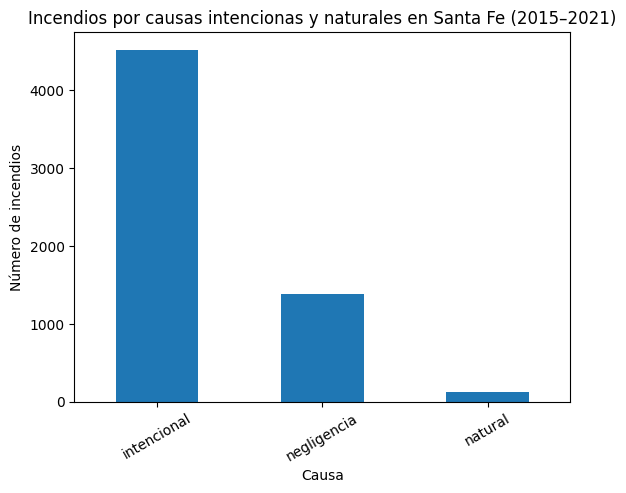

In [185]:
# Realizamos el gráfico.

totales = df_santa_fe[["intencional", 'negligencia', "natural"]].sum()

totales.plot(kind="bar")
plt.title("Incendios por causas intencionas y naturales en Santa Fe (2015–2021)")
plt.xlabel("Causa")
plt.ylabel("Número de incendios")
plt.xticks(rotation=30)
plt.show()

In [186]:
'''
Item 5. Obtenga el número promedio de incendios intencionales, por negligencia 
y naturales para la provincia de Río Negro durante el periodo 1993-2021.
'''

# Nos armamos un df con los datos de la provincia de Río Negro entre los años 1993-2021.
df_rio_negro = df_santa_fe = df[(df["provincia"] == "Río Negro") & (df["anio"] >= 1993) & (df["anio"] <= 2021)]
df_rio_negro = df_santa_fe.drop(columns=["provincia"])

df_rio_negro.head()

,anio,total,negligencia,intencional,natural,desconocida
14,1993,36,36,0,0,0
37,1994,258,251,7,0,0
60,1995,418,168,250,0,0
83,1996,361,73,11,27,250
105,1997,700,245,453,2,0


In [193]:
# Imprimimos los valores
for causa in ['intencional', 'negligencia', 'natural']:
    print(f'Promedio de incendios por causa "{causa}" en Rio Negro (1993-2021):',
            round(df_rio_negro[causa].mean(),2), '%')

Promedio de incendios por causa "intencional" en Rio Negro (1993-2021): 343.76 %
Promedio de incendios por causa "negligencia" en Rio Negro (1993-2021): 240.97 %
Promedio de incendios por causa "natural" en Rio Negro (1993-2021): 18.9 %
